# Second Model for multiclass classification on colour classes and faulty class

It has the same 9 different classes which are listed below :<br>
**1. blue <br>**
**2. cyan <br>**
**3. faulty <br>**
**4. green <br>**
**5. orange <br>**
**6. pink <br>**
**7. red <br>**
**8. white <br>**
**9. yellow <br>**

### Dataset is now inclusive of dark (previous collected dataset) and bright dataset

# 1. Exploratory Data Analysis

In [ ]:
from pathlib import Path

# Defining directories
merged_dir = Path.home() / "Documents" / "merged_dataset"
remaining_dark = merged_dir / "remaining_data_dark"
remaining_light = merged_dir / "remaining_data_light"
augmented_dark = merged_dir / "dark_augmented_data"
final_merged = merged_dir / "final_merged_data"

# Ensure folders exist, otherwise create
augmented_dark.mkdir(parents=True, exist_ok=True)
final_merged.mkdir(parents=True, exist_ok=True)

merged_dir

WindowsPath('C:/Users/Yin Yu/Documents/merged_dataset/split_data')

In [ ]:
# Visualizing numbers per class per folder

# Define folders to analyze
subfolders = ["remaining_data_dark", "remaining_data_light", "test_data"]

# Store results
class_counts = {}
total_counts = {}

# Loop for counts
for sub in subfolders:
    data_path = merged_dir / sub
    class_counts[sub] = {}
    total_counts[sub] = 0
    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            num_files = len(list(class_dir.glob("*.*")))
            class_counts[sub][class_dir.name] = num_files
            total_counts[sub] += num_files

for sub in subfolders:
    print(f"{sub}: {class_counts[sub]}")

total_counts

remaining_data_dark: {'blue': 83, 'cyan': 75, 'faulty': 75, 'green': 75, 'orange': 77, 'pink': 77, 'red': 77, 'white': 70, 'yellow': 75}
remaining_data_light: {'blue': 147, 'cyan': 153, 'faulty': 147, 'green': 147, 'orange': 147, 'pink': 147, 'red': 147, 'white': 153, 'yellow': 143}
test_data: {'blue': 45, 'cyan': 45, 'faulty': 45, 'green': 45, 'orange': 45, 'pink': 45, 'red': 45, 'white': 45, 'yellow': 45}


{'remaining_data_dark': 684, 'remaining_data_light': 1331, 'test_data': 405}

# 2. Data Preprocessing

## 2.1 Sorting data and pre-augmentation

### Do not run this upcoming cell if it was already run / split into respective files!

In [ ]:
# We want to pre-augment the current dark dataset and store it in a new dataset called augmented_dark data
# Augmentation on rotations and colour jitters

from PIL import Image
import shutil
import torchvision.transforms as T

augment = T.Compose([
    T.RandomRotation(degrees=(0, 360)),
    T.ColorJitter(brightness=(0.8, 1.3))
])

# Function to ensure class subfolders exist in a target directory
def ensure_class_folders(classes, root):
    for cls in classes:
        folder = root / cls
        folder.mkdir(parents=True, exist_ok=True)

class_names = [cls.name for cls in remaining_dark.iterdir() if cls.is_dir()]
ensure_class_folders(class_names, augmented_dark)
ensure_class_folders(class_names, final_merged)

# Loop through each class in the dark dataset
for cls in class_names:
    cls_path = remaining_dark / cls
    files = sorted([f for f in cls_path.iterdir() if f.suffix.lower() in ['.jpg', '.png']])

    for f in files:
        img = Image.open(f).convert("RGB")

        # Move original to final_merged
        shutil.move(str(f), final_merged / cls / f.name)

        # Augment and save to both augmented_dark and final_merged
        augmented = augment(img)
        new_fname = f.stem + "_aug" + f.suffix

        augmented.save(augmented_dark / cls / new_fname)
        augmented.save(final_merged / cls / new_fname)

# Move remaining light data into final merged
for cls in remaining_light.iterdir():
    if cls.is_dir():
        target_folder = final_merged / cls.name
        target_folder.mkdir(parents=True, exist_ok=True)
        for f in cls.glob("*.*"):
            shutil.move(str(f), target_folder / f.name)

print("✅ Augmentation & move complete. Data saved in:")
print(f" - {augmented_dark}")
print(f" - {final_merged}")


✅ Augmentation & move complete. Data saved in:
 - C:\Users\Yin Yu\Documents\merged_dataset\split_data\dark_augmented_data
 - C:\Users\Yin Yu\Documents\merged_dataset\split_data\final_merged_data


### Mini visualization of pre-augmented dark dataset

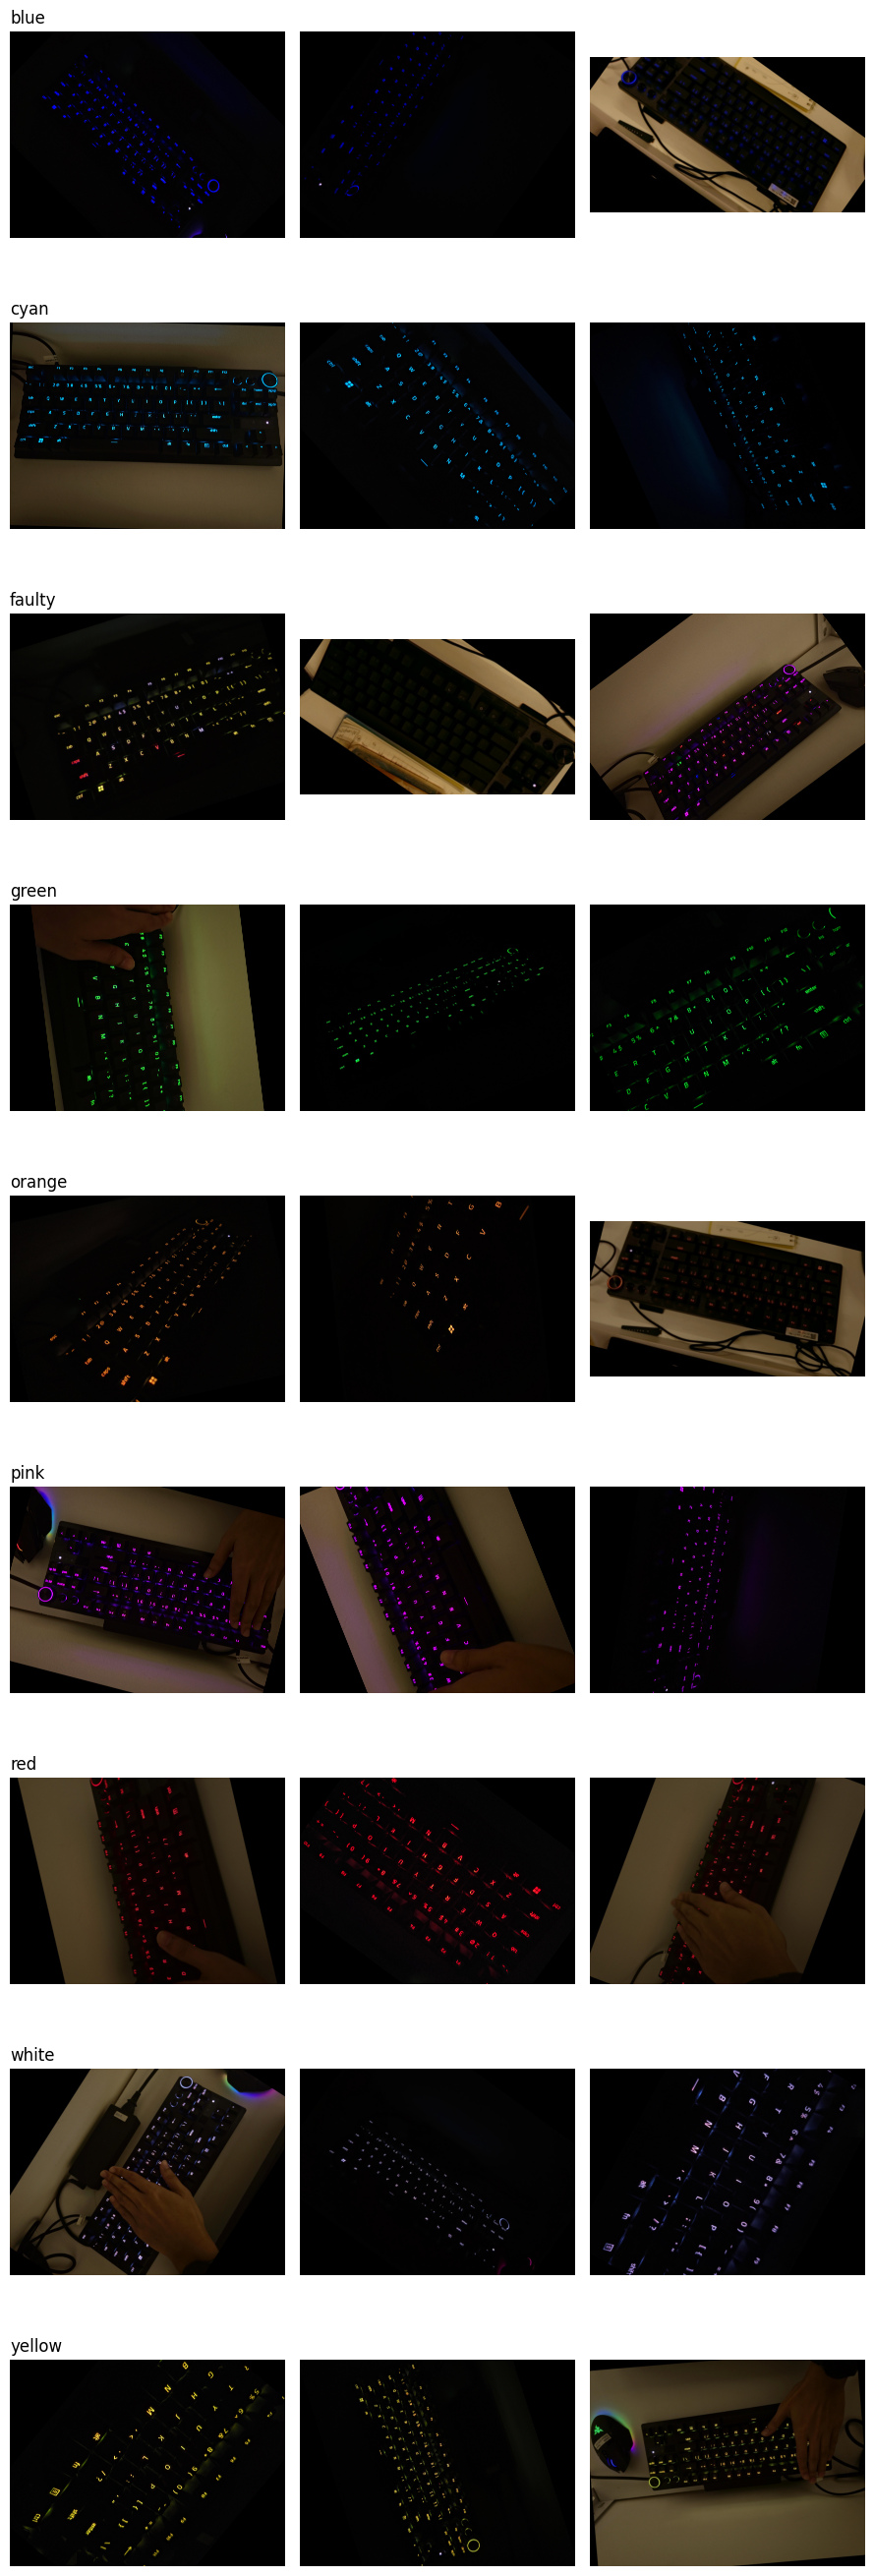

In [2]:
# Display some of the augmented data

from pathlib import Path
import matplotlib.pyplot as plt
import random
from PIL import Image

dark_augmented_dir = Path.home() / "Documents" / "merged_dataset" / "dark_augmented_data"

# Number of classes and samples per class to display
samples_per_class = 3

# Get all class folders
class_folders = sorted([f for f in dark_augmented_dir.iterdir() if f.is_dir()])

# Plot settings
fig, axes = plt.subplots(len(class_folders), samples_per_class, figsize=(samples_per_class * 3, len(class_folders) * 3))

for i, class_folder in enumerate(class_folders):
    images = list(class_folder.glob("*.*"))
    selected_images = random.sample(images, min(samples_per_class, len(images)))
    
    for j in range(samples_per_class):
        ax = axes[i, j] if len(class_folders) > 1 else axes[j]
        if j < len(selected_images):
            img = Image.open(selected_images[j])
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_folder.name, fontsize=12, loc='left')
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Visualizing numbers per class per folder after pre-augmentation and merging

merged_dir = Path.home() / "Documents" / "merged_dataset"

# Define folders to analyze
split_subfolders = ["remaining_data_dark", "remaining_data_light", "dark_augmented_data", "final_merged_data"]

# Store results
class_counts = {}
total_counts = {}

# Loop for counts
for sub in split_subfolders:
    data_path = merged_dir / sub
    class_counts[sub] = {}
    total_counts[sub] = 0
    for class_dir in data_path.iterdir():
        if class_dir.is_dir():
            num_files = len(list(class_dir.glob("*.*")))
            class_counts[sub][class_dir.name] = num_files
            total_counts[sub] += num_files

for sub in split_subfolders:
    print(f"{sub}: {class_counts[sub]}")

total_counts

remaining_data_dark: {'blue': 0, 'cyan': 0, 'faulty': 0, 'green': 0, 'orange': 0, 'pink': 0, 'red': 0, 'white': 0, 'yellow': 0}
remaining_data_light: {'blue': 0, 'cyan': 0, 'faulty': 0, 'green': 0, 'orange': 0, 'pink': 0, 'red': 0, 'white': 0, 'yellow': 0}
dark_augmented_data: {'blue': 83, 'cyan': 75, 'faulty': 75, 'green': 75, 'orange': 77, 'pink': 77, 'red': 77, 'white': 70, 'yellow': 75}
final_merged_data: {'blue': 0, 'cyan': 0, 'faulty': 0, 'green': 0, 'orange': 0, 'pink': 0, 'red': 0, 'white': 0, 'yellow': 0}


{'remaining_data_dark': 0,
 'remaining_data_light': 0,
 'dark_augmented_data': 684,
 'final_merged_data': 0}

Notice that the remaining_data_dark and light has been shifted to be merged into a new folder, including augmented_dark

Basically remaining_data_dark of 684 pics -> augmented one, augmented images into augmented folder, both shifted into final_merged_data with remaining_data_light

Total: 684 *2 + 1331 = 2699

In [4]:
# Visualize number of images per class

from collections import defaultdict

base_dir = Path.home() / "Documents" / "merged_dataset" / "split_data"
test_data = base_dir / "test_data"
final_merged = merged_dir / "final_merged_data"

# Initialize dictionary to store totals
class_totals = defaultdict(int)

# Function to count images per class
def count_images_per_class(folder: Path):
    for cls_folder in folder.iterdir():
        if cls_folder.is_dir():
            count = len(list(cls_folder.glob("*.*")))
            class_totals[cls_folder.name] += count

# Count from test and final_merged
count_images_per_class(test_data)
count_images_per_class(final_merged)

print(" | ".join([f"{cls}: {count}" for cls, count in sorted(class_totals.items())]))

blue: 60 | cyan: 60 | faulty: 45 | green: 63 | orange: 55 | pink: 55 | red: 55 | white: 55 | yellow: 55


## 2.2 Split final_merged_data for each class to validation and training datasets

## Do not run this if files are already split!

In [ ]:
# Paths
split_base = Path.home() / "Documents" / "merged_dataset" / "split_data"
merged_dir = Path.home() / "Documents" / "merged_dataset"
source_dir = merged_dir / "final_merged_data"

# Target folders at same level as test_data
train_dir = split_base / "train_data"
val_dir = split_base / "val_data"

# Create target dirs
train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)

val_count = 45  # number of images to move to validation per class

for class_folder in source_dir.iterdir():
    if class_folder.is_dir():
        class_name = class_folder.name
        images = list(class_folder.glob("*.*"))
        random.shuffle(images)

        val_images = images[:val_count]
        train_images = images[val_count:]

        # Ensure target class folders exist
        (train_dir / class_name).mkdir(parents=True, exist_ok=True)
        (val_dir / class_name).mkdir(parents=True, exist_ok=True)

        for img in val_images:
            shutil.move(str(img), val_dir / class_name / img.name)

        for img in train_images:
            shutil.move(str(img), train_dir / class_name / img.name)

print("✅ Files moved successfully into train_data and val_data.")

✅ Files moved successfully into train_data and val_data.


In [8]:
# Visualize number of images per class in each datasets and corresponding ratios

from pathlib import Path

split_base = Path.home() / "Documents" / "merged_dataset" / "split_data"
train_dir = split_base / "train_data"
val_dir = split_base / "val_data"
test_dir = split_base / "test_data"

class_names = sorted([f.name for f in test_dir.iterdir() if f.is_dir()])

output_train = []
output_val = []
output_test = []
for cls in class_names:
        train_count = len(list((train_dir / cls).glob("*.*")))
        val_count = len(list((val_dir / cls).glob("*.*")))
        test_count = len(list((test_dir / cls).glob("*.*")))
        
        total = test_count + val_count + train_count
        test_ratio = test_count / total * 100
        val_ratio = val_count / total * 100
        train_ratio = train_count / total * 100

        output_train.append(f"{cls}: {train_count} ({train_ratio:.1f}%)")
        output_val.append(f"{cls}: {val_count} ({val_ratio:.1f}%)")
        output_test.append(f"{cls}: {test_count} ({test_ratio:.1f}%)")


print("Train:", " | ".join(output_train))
print("Val  :", " | ".join(output_val))
print("Test :", " | ".join(output_test))

Train: blue: 285 (69.7%) | cyan: 275 (68.9%) | faulty: 226 (71.5%) | green: 272 (67.7%) | orange: 268 (70.2%) | pink: 268 (70.2%) | red: 268 (70.2%) | white: 260 (69.5%) | yellow: 260 (69.5%)
Val  : blue: 62 (15.2%) | cyan: 62 (15.5%) | faulty: 45 (14.2%) | green: 65 (16.2%) | orange: 57 (14.9%) | pink: 57 (14.9%) | red: 57 (14.9%) | white: 57 (15.2%) | yellow: 57 (15.2%)
Test : blue: 62 (15.2%) | cyan: 62 (15.5%) | faulty: 45 (14.2%) | green: 65 (16.2%) | orange: 57 (14.9%) | pink: 57 (14.9%) | red: 57 (14.9%) | white: 57 (15.2%) | yellow: 57 (15.2%)


# 2.3 Data Visualization

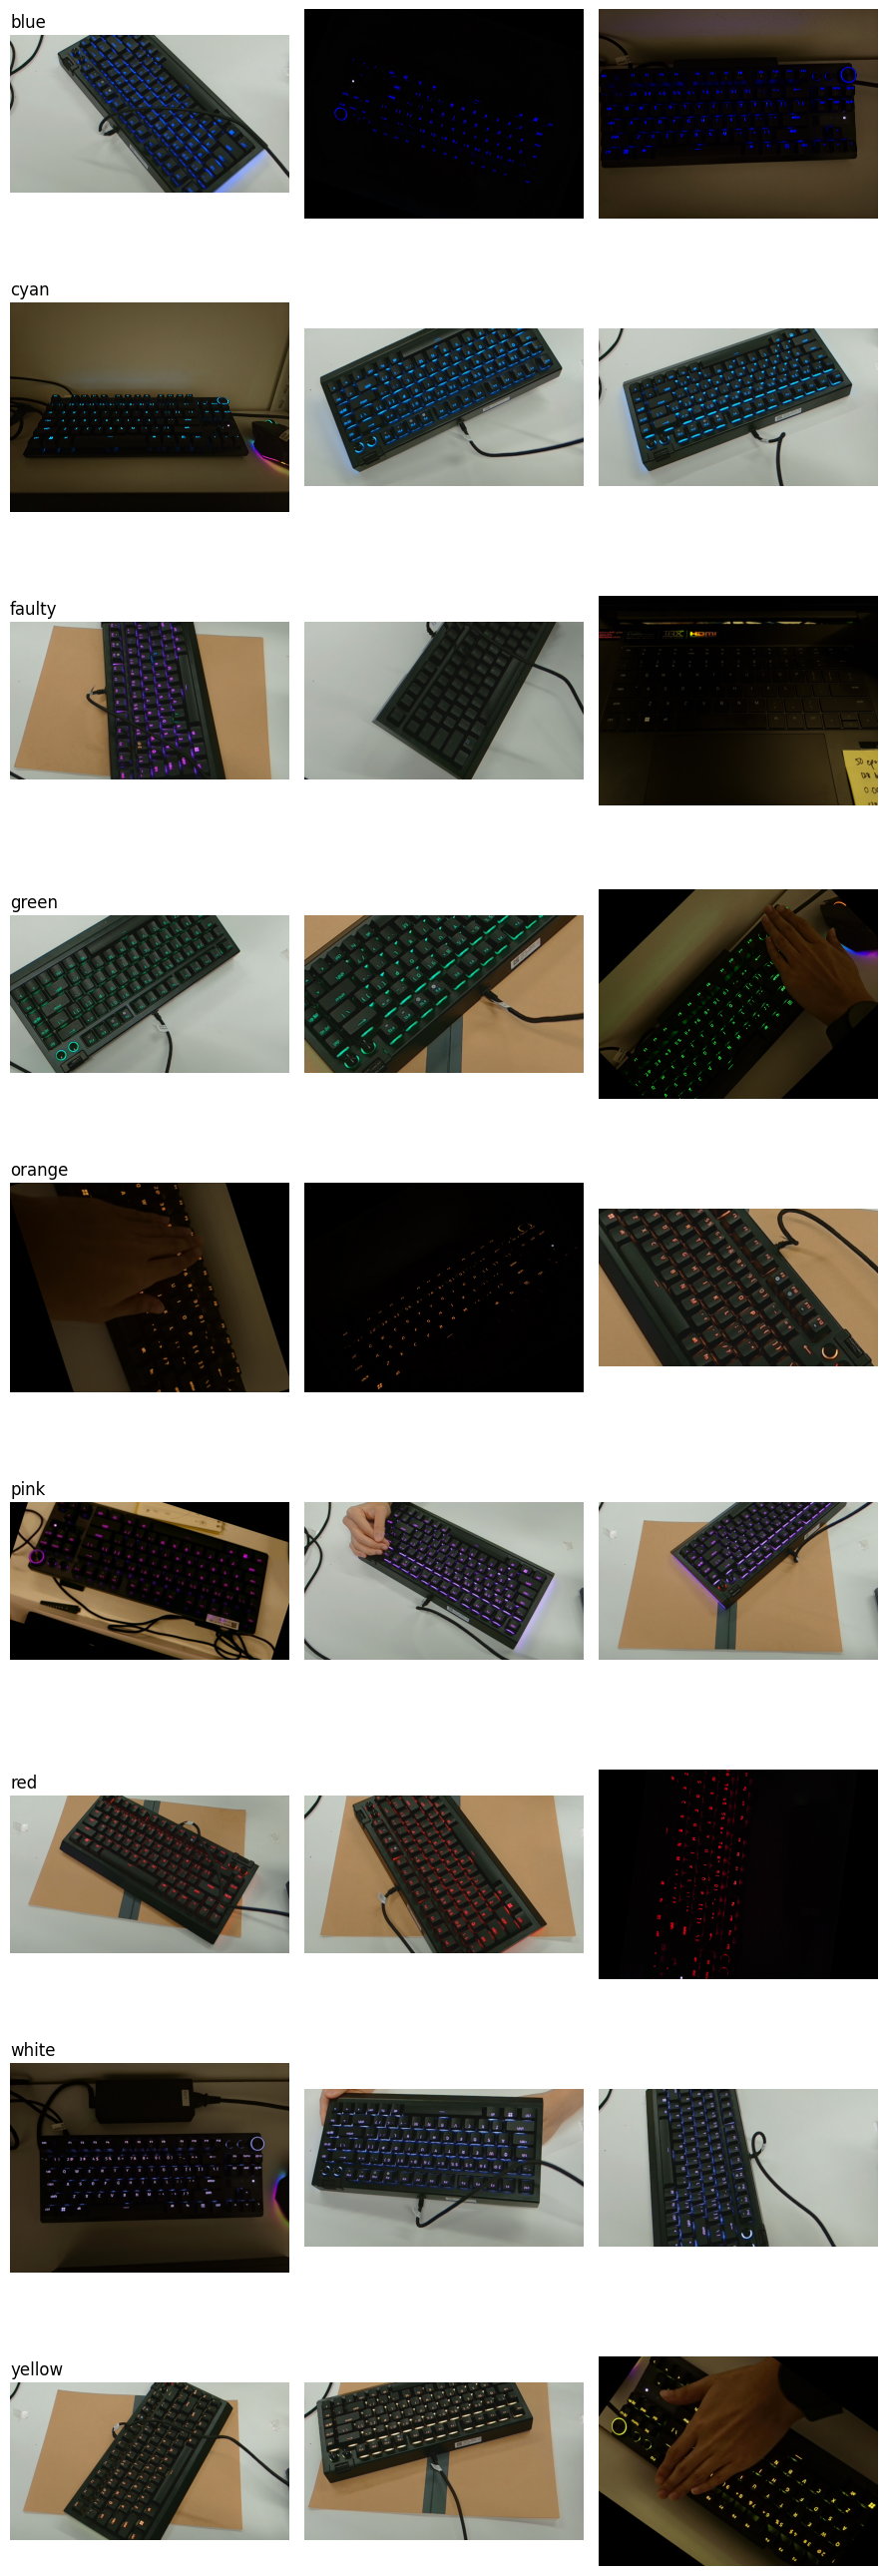

In [7]:
# Display some of the augmented data

import matplotlib.pyplot as plt
import random

train_dir = Path.home() / "Documents" / "merged_dataset" / "split_data" / "train_data"

# Number of classes and samples per class to display
samples_per_class = 3

# Get all class folders
class_folders = sorted([f for f in train_dir.iterdir() if f.is_dir()])

# Plot settings
fig, axes = plt.subplots(len(class_folders), samples_per_class, figsize=(samples_per_class * 3, len(class_folders) * 3))

for i, class_folder in enumerate(class_folders):
    images = list(class_folder.glob("*.*"))
    selected_images = random.sample(images, min(samples_per_class, len(images)))
    
    for j in range(samples_per_class):
        ax = axes[i, j] if len(class_folders) > 1 else axes[j]
        if j < len(selected_images):
            img = Image.open(selected_images[j])
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(class_folder.name, fontsize=12, loc='left')
        else:
            ax.axis('off')

plt.tight_layout()
plt.show()

## 2.4 Data Augmentation (On-the-fly)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = 224
batch_size = 32

split_base = Path.home() / "Documents" / "merged_dataset" / "split_data"
train_dir = split_base / "train_data"
val_dir = split_base / "val_data"
test_dir = split_base / "test_data"

train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalization
    rotation_range=20,          # mild rotations (since already did up to 360)
    brightness_range=[0.9, 1.1],  # small brightness tweaks
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=5,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)  # no augmentation for val/test

train_generator = train_datagen.flow_from_directory(
    directory=str(train_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'  # ensures one-hot encoding
)

val_generator = val_datagen.flow_from_directory(
    directory=str(val_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    directory=str(test_dir),
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False 
)

Found 2382 images belonging to 9 classes.
Found 519 images belonging to 9 classes.
Found 519 images belonging to 9 classes.


In [10]:
print("Class Indices (One-Hot Mapping):")
print(test_generator.class_indices)

Class Indices (One-Hot Mapping):
{'blue': 0, 'cyan': 1, 'faulty': 2, 'green': 3, 'orange': 4, 'pink': 5, 'red': 6, 'white': 7, 'yellow': 8}


# 3. Model Training

### Remember to change the version e.g _v5, ... when saving model and metrics! Everytime that a new model is trained (so as not to overwrite)

In [ ]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
import math
import numpy as np
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),  # Dropout to prevent overfitting
    layers.Dense(train_generator.num_classes, activation='softmax')  # Output layer for classification
])

loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# Compile Model
model.compile(
    optimizer='adam',
    loss=loss,
    metrics=['accuracy']
)

# Early Stopping Callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Class weights
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# # Custom manual tweaks to improve distinction from faulty
# class_weight_dict = {
#     0: 0.95,  # blue
#     1: 0.99,  # cyan
#     2: 0.98,  # faulty — reduced to discourage over-prediction
#     3: 1.01,  # green
#     4: 1.10,  # orange ↑
#     5: 1.10,  # pink   ↑
#     6: 1.10,  # red    ↑
#     7: 1.05,  # white
#     8: 1.10   # yellow ↑
# }

# Checkpoint to use model with best weights
checkpoint_path = "../models/checkpoints/best_model.h5"
checkpoint_cb = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False  # Set to False to save the full model
)

# Train Model
history = model.fit(
    train_generator,
    steps_per_epoch = math.ceil(train_generator.samples / train_generator.batch_size),
    epochs=20,
    validation_data=val_generator,
    validation_steps = math.ceil(val_generator.samples / val_generator.batch_size),
    callbacks=[early_stopping, checkpoint_cb],
    class_weight=dict(enumerate(class_weights)),
)

# Load the best model (based on val_loss)
best_model = tf.keras.models.load_model(checkpoint_path)

# Evaluate the best model
val_loss, val_accuracy = best_model.evaluate(val_generator)
print(f"Best Validation Loss: {val_loss}")
print(f"Best Validation Accuracy: {val_accuracy}")

# Optionally save again under a preferred name
best_model.save('../models/image_recognition/multiclass_img2_model_v11.h5')

# Get the parent folder of the current script
parent_dir = Path.cwd().parent

# Define the metrics folder path at the same level as the parent
metrics_path = os.path.join(parent_dir, "metrics/image_recognition") # joins "metrics" to it → puts the folder beside the parent
os.makedirs(metrics_path, exist_ok=True)

# Define metrics folder for multiclass_img2
subfolder_path = os.path.join(metrics_path, "multiclass_img2")
os.makedirs(subfolder_path, exist_ok=True)

# Save file there
with open(os.path.join(metrics_path, "multiclass_img2/multiclass_img2_history_v11.json"), "w") as f:
    json.dump(history.history, f)

Epoch 1/20
75/75 [==============================] - 108s 1s/step - loss: 1.8108 - accuracy: 0.4236 - val_loss: 0.9501 - val_accuracy: 0.7746
Epoch 2/20
75/75 [==============================] - 103s 1s/step - loss: 0.8667 - accuracy: 0.8384 - val_loss: 0.7325 - val_accuracy: 0.8960
Epoch 3/20
75/75 [==============================] - 101s 1s/step - loss: 0.7450 - accuracy: 0.8753 - val_loss: 0.6907 - val_accuracy: 0.8998
Epoch 4/20
75/75 [==============================] - 99s 1s/step - loss: 0.6926 - accuracy: 0.8833 - val_loss: 0.8843 - val_accuracy: 0.7881
Epoch 5/20
75/75 [==============================] - 100s 1s/step - loss: 0.6348 - accuracy: 0.9013 - val_loss: 0.6242 - val_accuracy: 0.9075
Epoch 6/20
75/75 [==============================] - 114s 2s/step - loss: 0.5918 - accuracy: 0.9194 - val_loss: 0.6303 - val_accuracy: 0.9114
Epoch 7/20
75/75 [==============================] - 106s 1s/step - loss: 0.5603 - accuracy: 0.9278 - val_loss: 0.5413 - val_accuracy: 0.9229
Epoch 8/20
75/

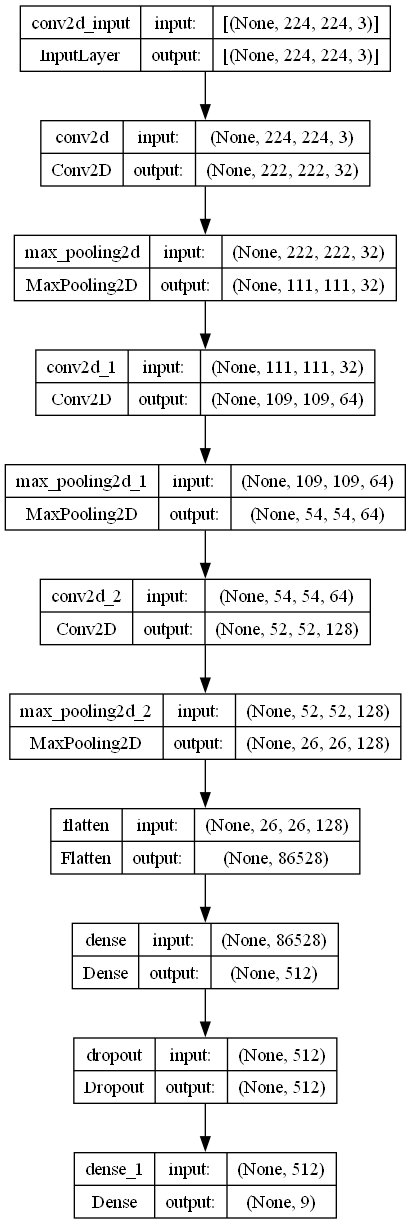

In [11]:
from keras.utils import plot_model

plot_model(model, to_file=os.path.join(metrics_path,'multiclass_img2/multiclass_img2_model_plot.png'), show_shapes=True, show_layer_names=True)

# 4. Model Evaluation

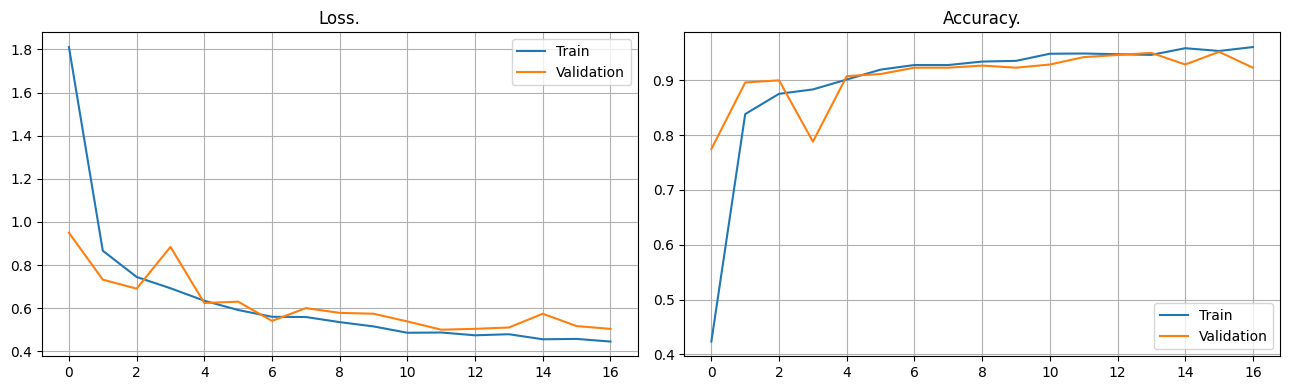

In [ ]:
# Extracting metrics

import matplotlib.pyplot as plt

metrics = history.history

train_loss = metrics["loss"]
train_accuracy = metrics["accuracy"]

validation_loss = metrics["val_loss"]
validation_accuracy = metrics["val_accuracy"]

# Visualizing metrics
plt.figure(figsize = (13,4))
plt.subplot(1,2,1)
plt.title("Loss.")
plt.plot(train_loss, label = "Train")
plt.plot(validation_loss, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

plt.subplot(1,2,2)
plt.title("Accuracy.")
plt.plot(train_accuracy, label = "Train")
plt.plot(validation_accuracy, label = "Validation")
plt.grid(True)
plt.legend(loc = "best")

# Save the figure
plt.tight_layout()
plt.savefig("../metrics/image_recognition/multiclass_img2/multiclass_img2_training_metrics_v11.png")
plt.show()
plt.close()

17/17 [==============================] - 19s 1s/step


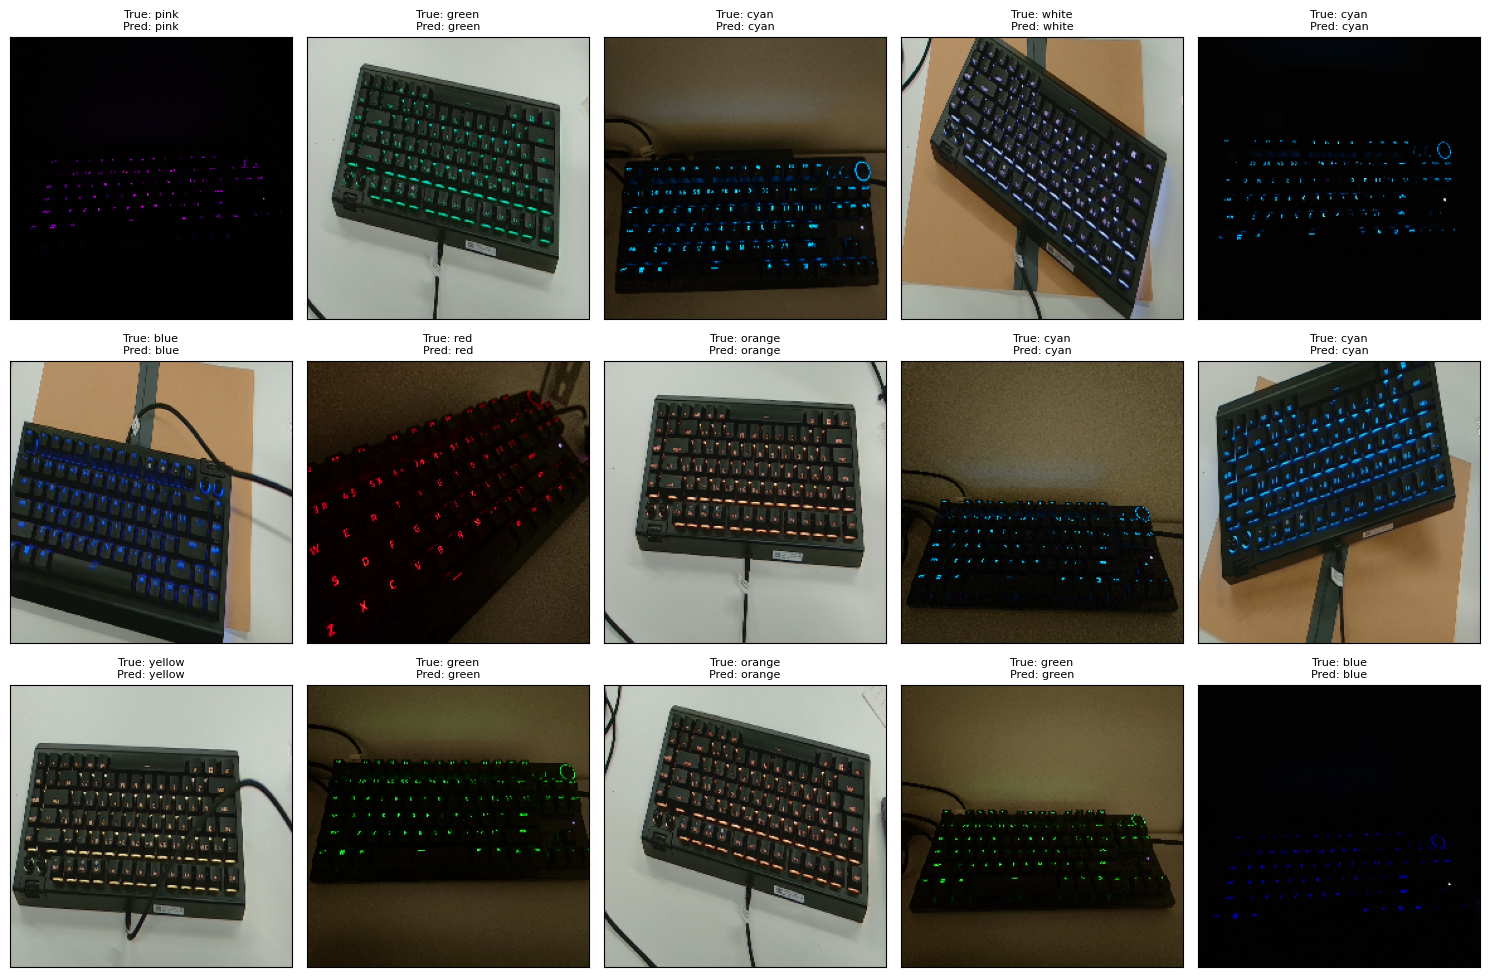

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Reset the generator to ensure predictions align
test_generator.reset()

# Get predictions on the full test set
result = best_model.predict(test_generator, verbose=1)
predicted_class = np.argmax(result, axis=1)
true_class = test_generator.classes
class_names = list(test_generator.class_indices.keys())
batch_size = test_generator.batch_size

# Choose random indices within the test set
num_random_images = 15
random_indices = np.random.choice(len(true_class), size=num_random_images, replace=False)

# Load all image batches from the generator (this gives us images in order)
all_images = []
for i in range(len(test_generator)):
    imgs, _ = test_generator[i]
    all_images.extend(imgs)

# Plot selected images with predictions
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img = all_images[idx]
    true_label_index = true_class[idx]
    predicted_label_index = predicted_class[idx]

    plt.subplot(3, 5, i + 1)
    plt.imshow(img)
    plt.xticks([]), plt.yticks([])
    plt.title(f"True: {class_names[true_label_index]}\nPred: {class_names[predicted_label_index]}", fontsize=8)

plt.tight_layout()
plt.show()


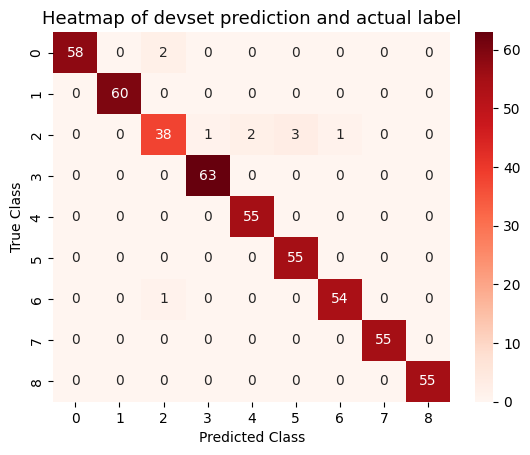

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculating confusion matrix
plt.title("Heatmap of devset prediction and actual label", fontsize = 13)
cm = confusion_matrix(true_class, predicted_class)
sns.heatmap(cm, cmap = "Reds", annot = True, fmt = "d")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")

# Save heatmap image
plt.savefig("../metrics/image_recognition/multiclass_img2/multiclass_img2_heatmap_metrics_v11.png")
plt.show()
plt.close()

Mappings:  {'blue': 0 | 'cyan': 1 | 'faulty': 2 | 'green': 3 | 'orange': 4 | 'pink': 5 | 'red': 6 | 'white': 7 | 'yellow': 8}

In [14]:
from sklearn.metrics import classification_report

# Understanding classification power of model on each class
report = classification_report(true_class, predicted_class)
print(report)

# Save it
with open(os.path.join(metrics_path, "multiclass_img2/classification_report_v11.txt"), "w") as f:
    f.write(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        62
           1       0.98      1.00      0.99        62
           2       1.00      0.71      0.83        45
           3       0.93      1.00      0.96        65
           4       0.98      1.00      0.99        57
           5       0.95      1.00      0.97        57
           6       0.98      1.00      0.99        57
           7       1.00      1.00      1.00        57
           8       0.98      1.00      0.99        57

    accuracy                           0.97       519
   macro avg       0.98      0.97      0.97       519
weighted avg       0.98      0.97      0.97       519



In [16]:
import io

# Create a stream to capture the printed summary
stream = io.StringIO()
model.summary(print_fn=lambda x: stream.write(x + '\n'))

# Get the string from the stream
model_summary = stream.getvalue()
print(model_summary)

# Save to file
with open(os.path.join(metrics_path, "multiclass_img2/model_summary.txt"), "w") as f:
    f.write(model_summary)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 111, 111, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 54, 54, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 26, 26, 128)      0

1/1 [==============================] - 0s 40ms/step


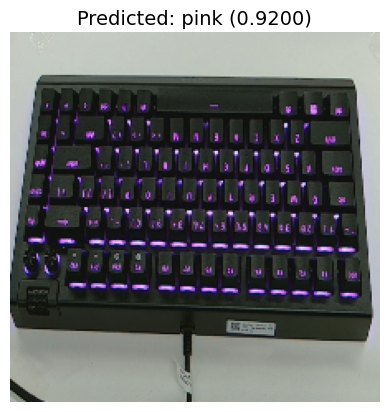

'pink'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image as keras_image

# Constants
img_size = 224
class_indices = {
    'blue': 0, 'cyan': 1, 'faulty': 2, 'green': 3,
    'orange': 4, 'pink': 5, 'red': 6, 'white': 7, 'yellow': 8
}

# Load the model
restored_model = tf.keras.models.load_model('../models/image_recognition/multiclass_img2_model_v11.h5')

def predict_single_image(img_path, model, class_indices, img_size):
    # Load and preprocess image
    img = keras_image.load_img(img_path, target_size=(img_size, img_size))
    img_array = keras_image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict using the model (softmax expected)
    prediction = model.predict(img_array)[0]  # Shape: (num_classes,)
    predicted_index = np.argmax(prediction)
    predicted_prob = prediction[predicted_index]

    # Convert index back to class label
    index_to_class = {v: k for k, v in class_indices.items()}
    predicted_label = index_to_class[predicted_index]

    # Show image and prediction
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {predicted_label} ({predicted_prob:.4f})", fontsize=14)
    plt.show()

    return predicted_label

# Set your image path
img_path = r"C:\Users\Yin Yu\Documents\cv_automation\Robot\pictures\photo (8).jpg"

# Run prediction
predict_single_image(img_path, restored_model, class_indices, img_size)